# Day 13 | End to End Toy Project
Is notebook me hum ek chhota sa Machine Learning project end-to-end banayenge — 
Student ki **IQ aur CGPA** ke aadhar par uska **Placement** predict karna.

**Pipeline Overview:**
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Selection & Splitting
4. Feature Scaling
5. Model Training & Evaluation
6. Model Deployment


**1- Yaha Sabse Pahele Libaray import karte hai**


In [1]:
import numpy as np
import pandas as pd 

**2- Pahele yaha pe haam deta add karenge bhai** 


In [2]:
data = pd.read_csv("All_dataSet/placement.csv")
data
df = data
df


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


**3- If you want over-view of Data Use *df.head*** 

In [3]:
df.head(7)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
5,5,7.1,48.0,1
6,6,5.7,143.0,0


**Note 1-   jab hamne  ye head wala chala ke dekh toh hame dikha ki *unnamed* wala coloum hai ye unnecsoury hai esse hame *Esse preprocessin karke hatna padega* Theek**

**4- For Checking data row and coloumn use** *df.shape*  **yad rakhna Yaha pe () ye nahi ata hai**

In [4]:
df.shape

(100, 4)

**5- Ab haam Yaha pe Ye sare Steps perform karenge**

**Pipeline Overview:**
1. Data Preprocessing
2. Exploratory Data Analysis (EDA)
3. Feature Selection & Splitting
4. Feature Scaling
5. Model Training & Evaluation
6. Model Deployment

## 1. Data Preprocessing...
- Sabse pehle dataset ko import karte hain.
- Jo columns model ke liye zaroori nahi hote (jaise `Unnamed: 0` ya ID columns), unhe drop kar dete hain.
- Model ko feed karne se pehle data ko **clean** karna zaroori hota hai — missing values, unnecessary columns, wrong datatypes sab check kiye jaate hain.


In [5]:
df = df.iloc[:,1:]
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


## 2. Exploratory Data Analysis (EDA)
- Matplotlib ka use karke data ko visualize karte hain.
- Ek **scatterplot** banate hain jisme x-axis pe CGPA aur y-axis pe IQ hota hai, color se placement (0/1) dikhaya jata hai.
- Isse pata chalta hai ki dono features (IQ, CGPA) placement ke saath kaisa pattern dikhate hain — kya linearly separable hai ya nahi.


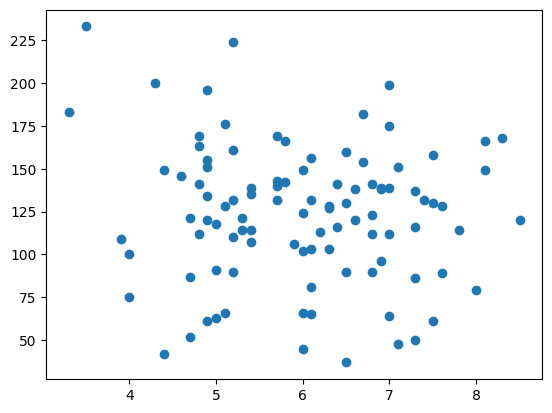

In [6]:
import matplotlib.pyplot as plt
plt.scatter(df['cgpa'], df['iq'])

* Note 2- Agr yaha Pe haam dekhe ki kiska placment ho gaya aur kiska nahi hua toh Ye code chalo 

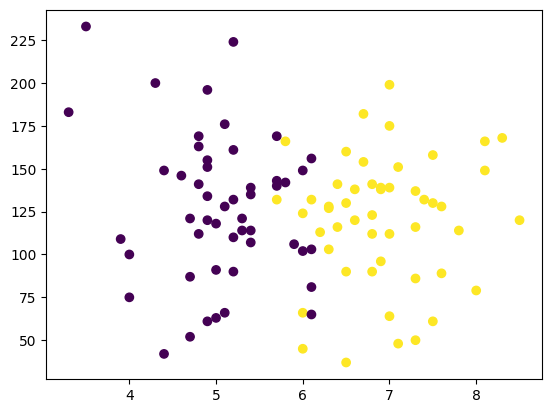

In [7]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
#hamne Espe Color Code kara hai 

### Algorithm Use - Logistic Regration 

* kyu kaise pata chala chala ye algorithm laga 
* jab Hamne EDA kara toh hame pata chal gaya data kaisa bikhra hun hai 
* sabse accha tarika Logistic Regration kaam a jata esme Aram se 
* Esliye Ye Algorithm usse kiya

### Extract input and Output Colounm

In [8]:
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

## 3. Feature Selection & Splitting
- Dataset ko do parts me divide karte hain:
  - **Input features (X):** IQ, CGPA
  - **Target variable (y):** Placement
- Fir `train_test_split` ka use karke data ko **training set** aur **testing set** me split karte hain.
- Isse hum model ko train karne ke baad, unseen data pe fairly evaluate kar paate hain.


### We Can use here Train Test First

#### Note : For This We Are Use Libaray Called - 


In [9]:
from sklearn.model_selection import train_test_split

**Esme Bass 3 Chezze Deni Hoti hai**
1. **Apka X (Matlbb apke Independent Variables)** 
2. **Apka Y (Apka Dependent Variable)** 
3. **Apko Ek Cheez batna padta hai apka test size kitna honga**


In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=42)

In [11]:
X_train

,cgpa,iq
18,4.0,100.0
30,7.6,128.0
73,4.9,61.0
33,6.0,149.0
90,7.3,86.0
...,...,...
60,6.9,139.0
71,6.1,132.0
14,6.1,103.0
92,5.2,110.0


In [12]:
X_test

,cgpa,iq
83,7.5,130.0
53,8.3,168.0
70,6.3,127.0
45,6.0,66.0
44,7.5,61.0
39,4.6,146.0
22,4.9,120.0
80,4.9,196.0
10,6.0,45.0
0,6.8,123.0


In [13]:
Y_train

18    0
30    1
73    0
33    0
90    1
     ..
60    1
71    1
14    0
92    0
51    0
Name: placement, Length: 90, dtype: int64

In [14]:
Y_test

83    1
53    1
70    1
45    1
44    1
39    0
22    0
80    0
10    1
0     1
Name: placement, dtype: int64

## 4. Feature Scaling
- IQ aur CGPA alag-alag range me hote hain (jaise IQ 80-140 aur CGPA 0-10).
- Isliye dono features ko ek standard range me laate hain (Standardization/Normalization).
- Isse Logistic Regression jaise algorithms better aur fast converge karte hain.


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
# Yaha pe Haam Object bana lengen
scaler = StandardScaler()

In [17]:
# ab hame simple chezo ko sacle kar dena hai kaise 
X_train_scaled = scaler.fit_transform(X_train)  # Ye fit Tranform Pahele Samjhega Data Me kya hai fhir usse tranform kar denga 
X_train_scaled

array([[-1.73718527, -0.62029848],
       [ 1.45537303,  0.09806189],
       [-0.9390457 , -1.62087186],
       [ 0.03645823,  0.63683217],
       [ 1.1893265 , -0.97947867],
       [-0.14090612,  0.45724208],
       [-0.9390457 ,  0.79076654],
       [ 1.1893265 , -1.90308486],
       [-0.49563482,  0.3802749 ],
       [-1.82586745, -0.38939693],
       [ 1.63273738, -0.26111829],
       [-1.38245657,  0.63683217],
       [ 0.92327998,  1.91961855],
       [ 1.45537303, -0.90251149],
       [ 2.2535126 , -0.10718393],
       [-0.76168135,  1.32953682],
       [-0.9390457 ,  0.25199626],
       [-1.38245657, -2.10833068],
       [-0.76168135, -1.49259322],
       [ 1.1893265 , -0.20980684],
       [ 0.8345978 ,  0.35461917],
       [-0.67299917,  0.9447009 ],
       [-0.14090612,  1.07297954],
       [-0.67299917, -0.87685576],
       [ 0.74591563, -0.31242975],
       [ 1.01196215, -1.95439632],
       [ 0.8345978 , -0.72292139],
       [ 1.8987839 ,  1.07297954],
       [ 0.74591563,

**Note-7  Yaha Kya Hua Mai Bat Deta hun**
**Sari Value traonformm ha gai hai**
1. Ye Data fram se Array Bann gaya hai ye bhi Yad rakhna hai

**Ab Yahi Same Cheez mai X_Test Ke uppe rbi appy karne wala hun**

In [18]:
X_test_scaled = scaler.transform(X_test)
# Kyu Maine tranform Use kiya kyu ki maine pattern ko fit_transform me samjh liya hai esliye dubara fit karne ka jarurat nahi hai 
X_test

,cgpa,iq
83,7.5,130.0
53,8.3,168.0
70,6.3,127.0
45,6.0,66.0
44,7.5,61.0
39,4.6,146.0
22,4.9,120.0
80,4.9,196.0
10,6.0,45.0
0,6.8,123.0


#### Yaha Tak Ab Haam Pahuch Gaye Ab Hame Model Ko Trained Karna Hai 

## 5. Model Training & Evaluation
- **Logistic Regression** model ko training data pe train karte hain.
- Model ki performance ko **accuracy score** se measure karte hain.
- Fir **decision boundary** plot karke visually dekhte hain ki model ne data ko kaise classify kiya hai.


In [19]:
from sklearn .linear_model import LogisticRegression

In [20]:
# Ab mai Ek Object bana raha hun 
clf = LogisticRegression()

**Note- Bhaa ye ***clf*** jo hai eske pass powers hai Unfunction ko execess karne ka jo Logistic-Regration CLass ke andhar hai aur wahi pe Ex Function Hota hai Called ***fit()*** Aur Fhir ko hi haam use karte hai model ko trained karne ke liye Bassusme apko trainig data provide karna hai**

In [21]:
clf.fit(X_train_scaled, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## ➡️ Model Evalution Karne Wale hai 

### **🤦‍♂️ Emse Haam Simple Acuracy Nikal te hia Kiske Teast Wale Data Pe**

In [22]:
y_pred = clf.predict(X_test_scaled)

##### **⬆️**
**NOTE 8- Predict() Ek Function Hai Esme Jab bhi Tum Naya Data Pass karoge jaise hamne yaha hamne X_test pass Kiya hai Hamne Esse Chupa diya tha training ke waqt Aur ab Esko haam jaise hi Run Karunga Toh Mere Model Ka Predication Niakal ke a jayega** 

In [23]:
Y_test

83    1
53    1
70    1
45    1
44    1
39    0
22    0
80    0
10    1
0     1
Name: placement, dtype: int64

➡️**Note-9 Ab haam yaha pe Side by Side Predication ka Acuracy dekh lenge Aur aur haam Esse Kitna Sahi kiya hai usse Count kar lenge aur fhir acuracy score calculate kar lenge done**

In [24]:
# Haam Yaha eske liye sckit learn use karnge heek hai na
from sklearn.metrics import accuracy_score

**1. ***accuracy_score(yaha pe sahi wala data batna hota hai , Yaha pe predication wala data batna hota hai)*****

**2. Fhir Hame Automatically accuracy score calculate karke de deta hai**

In [25]:

accuracy_score(Y_test, y_pred)

0.8

### Decision Boundrary

**Matlb yahi hai ki ML Model Ne kya patern notic kiya hamre data me usko agr haam visulize karna hai toh wo hame decision boundrary ko use karke Visulize Kiya ja sakta hai** 


<Axes: >

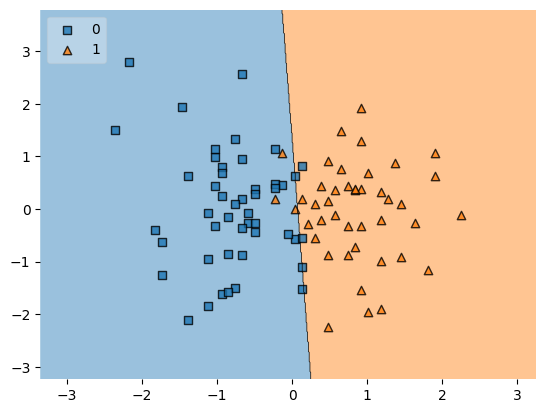

In [26]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(X_train_scaled, Y_train.values, clf=clf, legend=2)

### Ab Agr Sab Sahi Lag Rhaa hai toh Model ko Haam Yah Se Utha Ke serve pe dalne wale hai 

In [27]:
import pickle
# python me har object hote hai pickel uss object ko wo file me conver deta hai aur ab ess file ko utha ke haam kisisi bhi enviroment me use kar sakte hai 

In [28]:
pickle.dump(clf,open('model.pkl','wb'))
# 10_Machine-Learing\ML_ModelFiles\13_Note-Book_model.pkl  Ye file jo hame mili mili hai ye hi hara ML model hai 

## 6. Model Deployment
- Trained model ko **Pickle** library ke through ek file (`.pkl`) me save/export karte hain.
- Is saved model ko ek **web application** me integrate kiya ja sakta hai.
- Deployment ke liye common platforms: **Heroku, AWS, Google Cloud** discuss kiye gaye hain.


In [29]:
# yaha Pe SJo Bataya Gay Hai Wo hame Uppe rka diya hai
# yaha pe haam website me dalne wale the but abhi ye nahi kanrne wale hai esse bad me karenge  

**Yaha pe File pkl Wali hai Esse Hi Utha Ke Haam Pane Server pe Dump Karte hai Ya live kar deta hai**